# **LAB 1: LOGISTIC REGRESSION**

**Name:** Shishir Pandeya (ACE079BCT062)

## Background

**Aritificial Intellience** :
Artificial Intelligence(AI) is the branch of computer science that focuses on creating intelligent systems capable of performing tasks on reasoning, learning, decision-making and problem solving. AI systems can be rule-based or learning-based.

**Machine Learning**:
Machine Learning (ML) is a field of artificial intelligence that allows machine to learn from data by identifying patterns in data and use them to make predictions. It improves performance by learning with experience.

**Deep Learning**:
Deep Learning (DL) is a field of machine learning that uses artificial neural networks with multiple layers that try to simulate human neural network where neuron gives response based on given input. Deep learning models can automatically extract features from large amounts of data.

**Data Science**:
Data Science is the field of extracting and analyzing data using various statistics and data visualization. The extracted insights from the data is used to support decision making and solve real-world problems.

# **Task 1: Logistic Regression with a Single Feature**
Firstly, we build a simple logistic regression model using only one input feature. The input feature is "Cholestrol".

In [1]:
#importing dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

## 1. Data Retrieval and Collection
We will now load the heart disease dataset from the csv file.

In [2]:
try:
    df = pd.read_csv('Heart_Disease_Prediction.csv')
except FileNotFoundError:
    print("File not found. Please upload 'Heart_Disease_Prediction.csv' to your notebook environment.")

Check shape of dataset and column names.

In [3]:
# Display dataset shape and columns
print("Shape:", df.shape)
print("Columns:", df.columns)
df.head()

Shape: (270, 14)
Columns: Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


The shape output tells us that there are 270 rows and 14 columns.
The columns output lists out all 14 column names. 
df.head() gives first 5 data samples.


## 2. Data Cleaning
We check for missing values and ensure the target variable is binary.
In this dataset, the target column is named Heart Disease.

In [4]:
print(df.isnull().sum())

print(df.isnull().sum())

target_col = 'Heart Disease'
print(f"Unique values in '{target_col}':", df[target_col].unique())

if df[target_col].dtype == 'object':
    df[target_col] = df[target_col].map({'Presence': 1, 'Absence': 0})
    print("Converted target to binary (1=Presence, 0=Absence)")

print("Final unique values:", df[target_col].unique())

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64
Unique values in 'Heart Disease': ['Presence' 'Absence']
Converted target to binary (1=Presence, 0=Absence)
Final unique values: [1 0]


We examined the Cholesterol column and found to contain no missing or invalid values. The target variable Heart Disease was transformed from categorical labels (Presence/Absence) into a binary format, where 1 represents the presence of heart disease and 0 represents its absence. Finally,we reviewed the dataset to confirm the correctness and consistency of the final data types.

## 3. Feature Design
In this step, we select our input feature and target variable.
* Input Feature (X): Cholesterol
* Target Variable (y): Heart Disease

In [5]:
# 1. Select the Feature (X) and Target (y)
feature_col = 'Cholesterol'
target_col = 'Heart Disease'

# X must be a DataFrame (2D array), so we use double brackets
X = df[[feature_col]]

# y is a Series (1D array)
y = df[target_col]

# 2. Check the shapes to ensure dimensions match
print("Feature set (X) shape:", X.shape)
print("Target set (y) shape:", y.shape)

Feature set (X) shape: (270, 1)
Target set (y) shape: (270,)




Cholesterol is a key predictor of heart disease because high levels lead to buildup of fatty plaques in arteries. This condition narrows blood vessels and restricts blood flow to the heart and reduced blood flow increases the risk of heart attacks and strokes.

## 4. Algorithm Selection
We choose Logistic Regression for this task.


Unlike Linear Regression, which predicts a continuous number (like price), Logistic Regression is designed to predict the probability of an event occurring (e.g., "75% chance of Heart Disease").
* It uses the Sigmoid Function to squash the output between 0 and 1.
* It allows us to set a threshold (usually 0.5) to classify the result as either `1` (Presence) or `0` (Absence).

In [6]:
# Initialize the Logistic Regression model
# random_state=42 ensures the results are reproducible (same every time we run it)
#42 is a random number, can be any number
model = LogisticRegression(random_state=42)

## 5. Loss Function Selection
The Logistic Regression algorithm uses Binary Cross-Entropy (also known as Log Loss) to measure error during training.

### How does Log Loss work?
It functions as a penalty mechanism that assigns a high cost to predictions that are made with high confidence but are incorrect. For example, if the actual class is 1 (Disease is predicted) and the model predicts a very low probability such as 0.01, the resulting loss becomes significantly large. During training, the objective is to minimize this overall loss in order to obtain the optimal Sigmoid curve that best fits the data.

## 6. Model Learning
We will now split the data into a Training Set (80%) to teach the model and a Testing Set (20%) to evaluate it.

### Learning Parameters
When we run .fit(), the model iteratively adjusts its Intercept and Coefficient to minimize the Log Loss.

In [7]:
# 1. Split the data
# We use 'X' because that is what we named it in Step 3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 2. Train the model
model.fit(X_train, y_train)

# 3. Output the learned parameters
print("The model is trained successfully")
print(f"Learned Intercept (b): {model.intercept_[0]:.4f}")
print(f"Learned Coefficient (w): {model.coef_[0][0]:.4f}")

The model is trained successfully
Learned Intercept (b): -1.0470
Learned Coefficient (w): 0.0035


### Observation: Model Parameters
* **Intercept ($b = -1.0470$):** This represents the starting point of the model, showing the likelihood of heart disease when the cholesterol value is zero.
* **Coefficient ($w = 0.0035$):** Since the coefficient is positive, it suggests that higher cholesterol levels are associated with a slightly increased chance of heart disease.

## 7. Model Evaluation
We will now evaluate the model using the Testing Set. We will look at Accuracy, the Confusion Matrix, and visualize the results with a Sigmoid Curve.

Accuracy Score: 0.61

Confusion Matrix:
 [[28  5]
 [16  5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.85      0.73        33
           1       0.50      0.24      0.32        21

    accuracy                           0.61        54
   macro avg       0.57      0.54      0.52        54
weighted avg       0.58      0.61      0.57        54



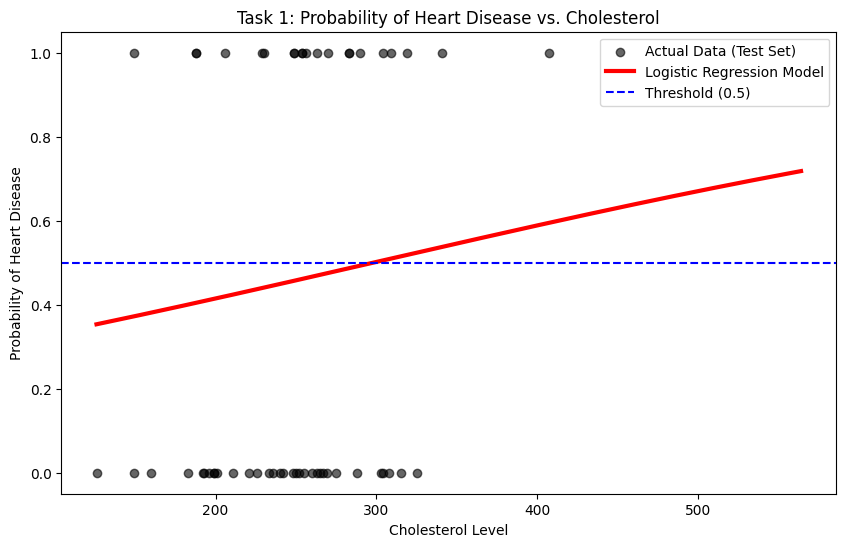

In [8]:
# 1. Generate Predictions on Test Data
y_pred = model.predict(X_test)

# 2. Print Evaluation Metrics
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 3. Plotting the Sigmoid Curve
plt.figure(figsize=(10, 6))

# A. Scatter plot of the actual test data
plt.scatter(X_test, y_test, color='black', alpha=0.6, label='Actual Data (Test Set)')

# B. Generate the red Sigmoid line
# FIX: Use df['Cholesterol'] instead of X_single so it works no matter what you named your variable
x_vals = np.linspace(df['Cholesterol'].min(), df['Cholesterol'].max(), 300).reshape(-1, 1)

# FIX: Convert to DataFrame with correct column name to silence the warning
x_df = pd.DataFrame(x_vals, columns=['Cholesterol'])

# Predict probability
y_prob = model.predict_proba(x_df)[:, 1]

# Plot line
plt.plot(x_vals, y_prob, color='red', linewidth=3, label='Logistic Regression Model')

# C. Formatting
plt.axhline(0.5, color='blue', linestyle='--', label='Threshold (0.5)')
plt.xlabel('Cholesterol Level')
plt.ylabel('Probability of Heart Disease')
plt.title('Task 1: Probability of Heart Disease vs. Cholesterol')
plt.legend()
plt.show()

## Observation and Interpretation
Accuracy: The model achieved an accuracy of 0.61 (61%). This means it correctly predicted the outcome for about 6 out of 10 patients, which is only slightly better than random guessing.

Confusion Matrix:

True Negatives: 28 (Healthy patients correctly identified)

False Positives: 5 (Healthy patients wrongly labeled as sick)

False Negatives: 16 (Sick patients wrongly labeled as healthy)

True Positives: 5 (Sick patients correctly identified)

Key Issue (Recall): The recall for Class 1 (Heart Disease) is very low at 0.24. This means the model only detected 24% of the actual heart disease cases. It missed 16 out of 21 sick patients.

## Conclusion: 
We found a large numner of false negatives and the flat sigmoid curve shows that only cholesterol does not do a good job of predicting heart disease. There is considerable overlap between healthy and diseased patients when only this feature is considered, which makes it hard for the model to separate the two groups clearly.

# ---------------------------------------------------------
# **Task 2: Logistic Regression with Multiple Features**


## 1 & 2. Data Retrieval and Cleaning
We reuse the cleaned dataset (df) from Task 1.
Data is loaded, missing values checked, and already target converted to binary.

## 3. Feature Design (All Features)
In Task 1, we saw that Cholesterol alone was a weak predictor. Now, we will use all available features (Age, Sex, Chest Pain Type, BP, etc.) to give the model more information.

### Data Preparation: Feature Normalization
Since the input features exist on very different scales (for example, cholesterol values are in the hundreds while sex is represented as 0 or 1), features with larger numeric ranges can dominate the learning process. To avoid this, StandardScaler is applied to standardize all features so that they have a mean of zero and a standard deviation of one. This scaling step allows the Logistic Regression model to consider each feature evenly and improves overall model performance.

In [9]:
# 1. Define Features (X) and Target (y)
# We drop the target column to keep EVERYTHING else as input
X_multi = df.drop(columns=['Heart Disease'])
y_multi = df['Heart Disease']

# 2. Scale the Features
scaler = StandardScaler()
X_multi_scaled = pd.DataFrame(scaler.fit_transform(X_multi), columns=X_multi.columns)

# 3. Verify
print("New Feature Shape:", X_multi_scaled.shape)
X_multi_scaled.head()

New Feature Shape: (270, 13)


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,1.712094,0.689500,0.870928,-0.075410,1.402212,-0.417029,0.981664,-1.759208,-0.701222,1.181012,0.676419,2.472682,-0.875706
1,1.382140,-1.450327,-0.183559,-0.916759,6.093004,-0.417029,0.981664,0.446409,-0.701222,0.481153,0.676419,-0.711535,1.189277
2,0.282294,0.689500,-1.238045,-0.411950,0.219823,-0.417029,-1.026285,-0.375291,-0.701222,-0.656118,-0.954234,-0.711535,1.189277
3,1.052186,0.689500,0.870928,-0.187590,0.258589,-0.417029,-1.026285,-1.932198,1.426081,-0.743600,0.676419,0.349871,1.189277
4,2.152032,-1.450327,-1.238045,-0.636310,0.374890,-0.417029,0.981664,-1.240239,1.426081,-0.743600,-0.954234,0.349871,-0.875706


13 columns indicates that we successfully dropped target column and kept only input featues. The table with Z-scores betwwen -3 and +3 indicated StandardScaler worked correctly.

## 4, 5, & 6. Model Selection, Loss, and Training
We repeat the training pipeline using the new, scaled multi-feature dataset.
* Algorithm: Logistic Regression.
* Loss: Binary Cross Entropy.

In [10]:
# 1. Split the data (80% Train, 20% Test)
# We use new variable names (_m) to distinguish from Task 1
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi_scaled, y_multi, test_size=0.20, random_state=42)

# 2. Initialize and Train
model_multi = LogisticRegression(random_state=42)
model_multi.fit(X_train_m, y_train_m)

print("Multi-Feature Model Trained.")
print(f"Intercept: {model_multi.intercept_[0]:.4f}")
# We skip printing coefficients because there are 13 of them now!

Multi-Feature Model Trained.
Intercept: -0.3241


### Observation: Model Parameters (Multi-Feature)
* **Intercept ($b_0 = -0.3241$):**
   Since the features were standardized, a value of zero represents the average level for each variable. The intercept describes the model starting belief about heart disease for a patient who has average characteristics across all features. Since the intercept is negative, the model initially leans toward predicting that such an average patient is healthy. In simple terms, for an average patient, the model begins with a baseline assumption of a higher likelihood of being healthy than sick.

## 7. Model Evaluation (Task 2)
We evaluate the multi-feature model using the same metrics. We can expect higher accuracy and recall because the model can now look at multiple parameters.


In [11]:
# 1. Generate Predictions
y_pred_m = model_multi.predict(X_test_m)

# 2. Metrics
print(f"Accuracy Score: {accuracy_score(y_test_m, y_pred_m):.2f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test_m, y_pred_m))
print("\nClassification Report:\n", classification_report(y_test_m, y_pred_m))

Accuracy Score: 0.91

Confusion Matrix:
 [[31  2]
 [ 3 18]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



### Observation and Interpretation (Task 2)

The model performed very well, achieving an accuracy of 91% and recall of 86%.

Confusion Matrix:
True Negatives: 31 healthy patients were correctly identified
False Positives: 2 healthy patients were incorrectly labeled as sick
False Negatives: 3 sick patients were missed
True Positives: 18 sick patients were correctly identified

### Conclusion: 
By using all available features, the model has become a reliable for diagnosing heart disease with high precision.


# **Model Comparison & Conclusion**

### 1. Which model performs better and why?
The multi-feature model from Task 2 clearly outperforms the single-feature model from Task 1.

* Task 1 (Cholesterol only): Accuracy was 61%
* Task 2 (All features): Accuracy improved to 91%

Heart disease is influenced by multiple factora and hence it cannot accurately be predicted with cholesterol alone.

### 2. How does adding more features affect Accuracy and Recall?

When we included additional features, it led to significant improvement in the model performance,  addressing the recall issue observed in Task 1.

| Metric   | Task 1 (Single Feature) | Task 2 (All Features) | Observation |
|----------|------------------------|----------------------|-------------|
| Accuracy | 61%                    | 91%                  | Accuracy increased by 30%, meaning the model makes far fewer random or incorrect guesses. |
| Recall   | 24%                    | 86%                  | In Task 1, most sick patients were missed, whereas in Task 2 the model correctly identified almost all (18 out of 21) sick patients. |

Adding more patient features provided the model with a complete picture, allowing it to separate healthy and diseased patients much more reliably.


### 3. Trade-offs between Interpretability and Performance
There is often a balance between how easy a model is to understand and how well it performs.
* Task 1 (High Interpretability, Low Performance):
    * Since there is only one feature, we could easily plot this on a 2D graph (Sigmoid curve) and visually observe the relationship.
    * Although the model is simple to explain i.e. increase in cholesterol may increase the risk of heart disease but it is too limited in real world applications.
* Task 2 (Low Interpretability, High Performance):
    * Since there are multiple features(13 features), it is difficult to visualize it on a graph. So we use different accuracy metrics and recall to evaluate its performance.
    * We lose the ability to easily visualize and explain the model, but we gain a high level of accuracy. In medical applications, accurate identification of patients is more important than simple visual representation of model.

### 4. Final Conclusion
To properly diagnose patients, cholesterol alone was insufficient. However, the accuracy was found to increase to 91% when all health parameters were taken into account. This demonstrates how much more accurately cardiac disease can be predicted when the complete patient profile is used.